# TCC 2 - Predição de Safra

## Carregamento e Preparação Inicial

In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carregando os arquivos
print("Carregando os datasets...")
df_clima = pd.read_csv('../Data/agroclimatologia_completa_enso.csv')
df_prod = pd.read_csv('../Data/produtividade_soja_completa.csv')

# Convertendo a coluna de data de string para o formato datetime
df_clima['data'] = pd.to_datetime(df_clima['data'])


print("Transformando dados de produtividade (Wide -> Long)...")
# Lista com os anos que estão como colunas
anos_safra = [str(ano) for ano in range(2004, 2025)]

# Aplicando o pd.melt para empilhar os anos
df_prod_long = pd.melt(
    df_prod,
    id_vars=['codigo_ibge', 'name'], # Colunas que mantidas fixas
    value_vars=anos_safra,           # Colunas que serão derretidas
    var_name='ano_safra',            # Nome da nova coluna de anos
    value_name='produtividade_kg_ha' # Nome da variável alvo
)

df_prod_long['ano_safra'] = df_prod_long['ano_safra'].astype(int)
df_prod_long = df_prod_long.dropna(subset=['produtividade_kg_ha'])

# Resultados
print(f"Base de clima carregada com {df_clima.shape[0]} linhas e {df_clima.shape[1]} colunas.")
print(f"Base de produtividade alinhada com {df_prod_long.shape[0]} registros válidos.")
display(df_prod_long.head())

# Se quiser salvar depois
# df_prod_long.to_csv('produtividade_long_derretida.csv', index=False)

Carregando os datasets...
Transformando dados de produtividade (Wide -> Long)...
Base de clima carregada com 2931949 linhas e 42 colunas.
Base de produtividade alinhada com 7329 registros válidos.


,codigo_ibge,name,ano_safra,produtividade_kg_ha
0,4100103,Abatiá,2004,2600.0
1,4100459,Altamira do Paraná,2004,3100.0
2,4100608,Alto Paraná,2004,1487.0
3,4100707,Alto Piquiri,2004,2300.0
4,4100509,Altônia,2004,1050.0


## Janelamento Temporal

In [9]:
import pandas as pd
import numpy as np

# Função para calcular a amplitude (Max - Min)
def amplitude(x):
    return x.max() - x.min()

# Renomeando a função para que a coluna no Pandas fique com o nome 'amplitude'
amplitude.__name__ = 'amplitude'

def criar_janela_climatica(df_clima, ano_safra, mes_previsao, janela_meses):
    """
    Filtra os dados climáticos para uma janela de X meses antes do mês de previsão
    e extrai as estatísticas descritivas complexas e o índice ENSO (ONI).
    """
    # Ajustando o Ano (Safra ocorre entre Setembro e Maio)
    ano_civil = ano_safra if mes_previsao <= 5 else ano_safra - 1
    
    # Data exata em que a previsão será feita (ex: 1º de Janeiro)
    data_ref = pd.to_datetime(f"{ano_civil}-{mes_previsao:02d}-01")
    
    # Data de início da janela PASSADA (ex: 2 meses atrás)
    data_inicio = data_ref - pd.DateOffset(months=janela_meses)
    
    # Filtrando o dataset de clima estritamente para a janela de tempo climática
    mascara = (df_clima['data'] >= data_inicio) & (df_clima['data'] < data_ref)
    df_janela = df_clima[mascara]
    
    # Se por algum motivo não houver dados na janela climática, retorna vazio para evitar erros
    if df_janela.empty:
        return pd.DataFrame()
    
    # Lista de estatísticas que usaremos
    # std = desvio padrão, skew = assimetria, kurt = curtose
    stats_base = ['mean', 'median', 'min', 'max', amplitude, 'std', 'skew', 'kurt']

    colunas_ignorar = ['fdata', 'data', 'codigo_ibge', 'latitude', 'longitude', 'fenomeno_enso', 'fenomeno_enso_numerico', 'oni']
    
    variaveis_climaticas = [col for col in df_clima.columns if col not in colunas_ignorar]
    
    agg_dict = {}
    for var in variaveis_climaticas:
        if var == 'PRECTOTCORR':
            # A precipitação recebe a soma (acumulado) + as estatísticas base
            agg_dict[var] = ['sum'] + stats_base
        else:
            # Todas as outras recebem apenas as estatísticas base
            agg_dict[var] = stats_base
            
    # Agrupamento por município usando o dicionário dinâmico
    df_agg = df_janela.groupby('codigo_ibge').agg(agg_dict)
    
    # Achatando as colunas
    df_agg.columns = [f"{col[0]}_{col[1]}" for col in df_agg.columns]
    
    # Tratamento do Índice ENSO (ONI)
    df_enso = df_janela.groupby('codigo_ibge').agg({
        'oni': 'last',                      
        'fenomeno_enso': 'last',            
        'fenomeno_enso_numerico': 'last'    
    })
    
    # Juntar os atributos climáticos com o ENSO
    df_final = df_agg.join(df_enso).reset_index()
    
    # Anexar informações de contexto
    df_final['ano_safra'] = ano_safra
    df_final['mes_previsao'] = mes_previsao
    df_final['janela_meses'] = janela_meses
    
    return df_final

## Loop de Janelamento e Cruzamento Final

In [10]:
# Definindo as regras da metodologia
meses_previsao_safra = [11, 1, 3, 5] # Novembro, Janeiro, Março, Maio
tamanhos_janela_climatica = [1, 2, 3] # Janelas climáticas de 1, 2 e 3 meses passados
anos_safra = df_prod_long['ano_safra'].unique() # Todos os anos que temos na base de produção

lista_datasets_janelas = []

# Loop por todas as combinações
for ano in anos_safra:
    for mes in meses_previsao_safra:
        for janela in tamanhos_janela_climatica:
            # Gerandondo a janela climática
            df_temp = criar_janela_climatica(df_clima, ano, mes, janela)
            
            if not df_temp.empty:
                lista_datasets_janelas.append(df_temp)

# Concatenando todos os blocos em um único DataFrame de clima achatado
df_clima_completo = pd.concat(lista_datasets_janelas, ignore_index=True)

# Cruzamento Final (Merge) com a tabela de Produtividade (Target)
df_master = pd.merge(
    df_clima_completo, 
    df_prod_long, 
    on=['codigo_ibge', 'ano_safra'], 
    how='inner'
)

print(f"Dataset final (df_master) construído com sucesso!")
print(f"Total de amostras prontas para o Machine Learning: {df_master.shape[0]} linhas.")
display(df_master.head())

Dataset final (df_master) construído com sucesso!
Total de amostras prontas para o Machine Learning: 87948 linhas.


,codigo_ibge,T2M_mean,T2M_median,T2M_min,T2M_max,T2M_amplitude,T2M_std,T2M_skew,T2M_kurt,T2M_MAX_mean,...,ALLSKY_SFC_UV_INDEX_skew,ALLSKY_SFC_UV_INDEX_kurt,oni,fenomeno_enso,fenomeno_enso_numerico,ano_safra,mes_previsao,janela_meses,name,produtividade_kg_ha
0,4100103,21.935161,22.37,16.77,26.53,9.76,2.541221,-0.376833,-0.763270,29.552581,...,-5.567685,30.999392,0.2,Neutro,0,2004,11,1,Abatiá,2600.0
1,4100459,20.538387,21.08,15.58,23.47,7.89,2.225788,-0.665804,-0.539717,26.904194,...,-3.728110,12.716813,0.2,Neutro,0,2004,11,1,Altamira do Paraná,3100.0
2,4100509,24.056452,24.34,19.71,27.67,7.96,2.276002,-0.479303,-0.784229,31.563548,...,-5.567671,30.999284,0.2,Neutro,0,2004,11,1,Altônia,1050.0
3,4100608,23.731613,23.94,19.33,27.19,7.86,2.202570,-0.465222,-0.819644,31.552903,...,-3.728117,12.716845,0.2,Neutro,0,2004,11,1,Alto Paraná,1487.0
4,4100707,24.056452,24.34,19.71,27.67,7.96,2.276002,-0.479303,-0.784229,31.563548,...,-5.567655,30.999165,0.2,Neutro,0,2004,11,1,Alto Piquiri,2300.0


## Validação Cronológica

In [11]:
print("Iniciando a divisão temporal dos dados...")

# Definindo a fronteira temporal (Treino até 2020, Teste 2021-2024)
ano_corte = 2020

df_treino = df_master[df_master['ano_safra'] <= ano_corte].copy()
df_teste = df_master[df_master['ano_safra'] > ano_corte].copy()

# A Variável Alvo (Target - y) é a produtividade
y_train = df_treino.pop('produtividade_kg_ha')
y_test = df_teste.pop('produtividade_kg_ha')

# Removendo identificadores que não são variáveis de clima
colunas_para_remover = ['codigo_ibge', 'name', 'fenomeno_enso', 'ano_safra']

X_train = df_treino.drop(columns=colunas_para_remover, errors='ignore')
X_test = df_teste.drop(columns=colunas_para_remover, errors='ignore')

print("Divisão concluída com sucesso!")
print("-" * 40)
print(f"Dados de TREINO (2004-{ano_corte}): {X_train.shape[0]} amostras.")
print(f"Dados de TESTE (2021-2024): {X_test.shape[0]} amostras.")
print(f"Total de Features de Entrada (X): {X_train.shape[1]} atributos climáticos.")

Iniciando a divisão temporal dos dados...
Divisão concluída com sucesso!
----------------------------------------
Dados de TREINO (2004-2020): 71196 amostras.
Dados de TESTE (2021-2024): 16752 amostras.
Total de Features de Entrada (X): 277 atributos climáticos.


## Treinamento e Avaliação do Baseline

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Treinando o Modelo de Referência (CART)...")

# Instanciando o modelo
modelo_cart = DecisionTreeRegressor(max_depth=10, random_state=42)

# Treinamento com as safras antigas (2004 a 2020)
modelo_cart.fit(X_train, y_train)

# Predição nas safras recentes (2021 a 2024)
y_pred_cart = modelo_cart.predict(X_test)


mae_cart = mean_absolute_error(y_test, y_pred_cart)
rmse_cart = np.sqrt(mean_squared_error(y_test, y_pred_cart))

print("-" * 40)
print("Resultados do Modelo Baseline (CART) nas safras recentes (2021-2024):")
print(f"MAE: {mae_cart:.2f} kg/ha (Erro absoluto médio)")
print(f"RMSE: {rmse_cart:.2f} kg/ha (Penalizando grandes desvios)")

Treinando o Modelo de Referência (CART)...
----------------------------------------
Resultados do Modelo Baseline (CART) nas safras recentes (2021-2024):
MAE: 837.49 kg/ha (Erro absoluto médio)
RMSE: 1012.49 kg/ha (Penalizando grandes desvios)
----------------------------------------


## Treinamento dos Modelos Ensemble

In [15]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Treinando o Random Forest (Bagging)...")
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("Treinando o XGBoost (Boosting)...")
modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)

# Cálculo das Métricas para Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Cálculo das Métricas para XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("-" * 40)
print("Resultados dos Modelos Ensemble (Teste Cego: 2021-2024):")
print(f"Random Forest - MAE: {mae_rf:.2f} kg/ha | RMSE: {rmse_rf:.2f} kg/ha")
print(f"XGBoost       - MAE: {mae_xgb:.2f} kg/ha | RMSE: {rmse_xgb:.2f} kg/ha")

Treinando o Random Forest (Bagging)...
Treinando o XGBoost (Boosting)...
----------------------------------------
Resultados dos Modelos Ensemble (Teste Cego: 2021-2024):
Random Forest - MAE: 808.65 kg/ha | RMSE: 938.90 kg/ha
XGBoost       - MAE: 782.72 kg/ha | RMSE: 913.18 kg/ha


## Importância dos Atributos

Gerando Feature Importance do Random Forest...


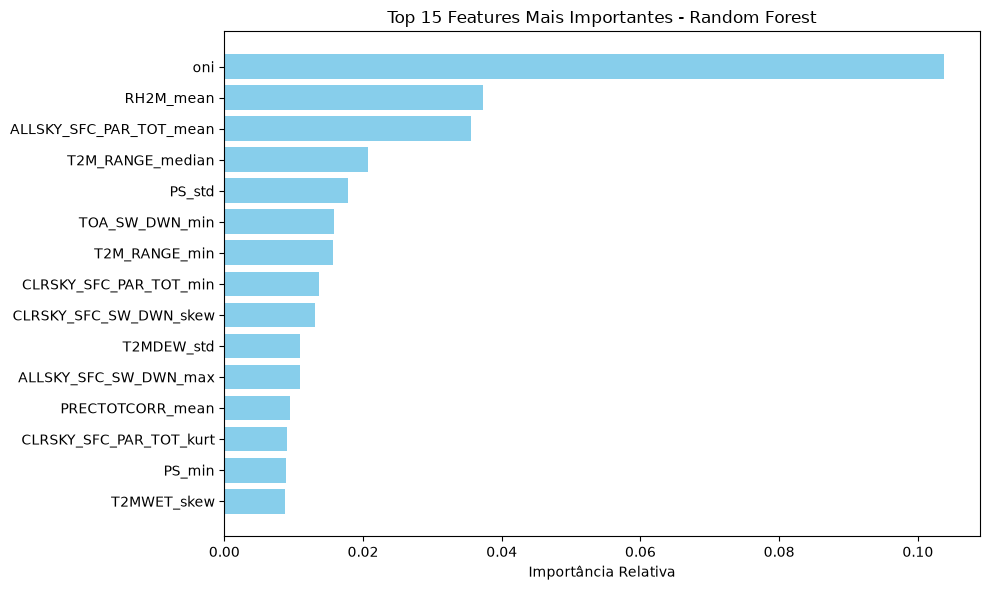

,Feature,Importância
273,oni,0.103775
64,RH2M_mean,0.037362
233,ALLSKY_SFC_PAR_TOT_mean,0.035500
25,T2M_RANGE_median,0.020754
86,PS_std,0.017895
227,TOA_SW_DWN_min,0.015743
26,T2M_RANGE_min,0.015665
243,CLRSKY_SFC_PAR_TOT_min,0.013702
223,CLRSKY_SFC_SW_DWN_skew,0.013076
45,T2MDEW_std,0.010947


In [17]:
import matplotlib.pyplot as plt

print("Gerando Feature Importance do Random Forest...")

features = X_train.columns
importancias_rf = modelo_rf.feature_importances_

df_importancias_rf = pd.DataFrame({
    'Feature': features,
    'Importância': importancias_rf
}).sort_values(by='Importância', ascending=False)

# Selecionando as 15 mais importantes
top_15_rf = df_importancias_rf.head(15)

# Plot do gráfico
plt.figure(figsize=(10, 6))
plt.barh(top_15_rf['Feature'][::-1], top_15_rf['Importância'][::-1], color='skyblue')
plt.title('Top 15 Features Mais Importantes - Random Forest')
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.show()

display(top_15_rf)

## Tabela de Comparação

Montando a tabela de comparação Real vs Predito por Município e Janela...

Exemplo de Predições Individuais (Municípios no Teste Cego)


,name,ano_safra,mes_previsao,janela_meses,Produtividade_Real,Predicao_RF,Predicao_XGB,Erro_Absoluto_XGB
75326,Santa Tereza do Oeste,2021,5,3,3554.0,2670.825833,2807.818115,746.181885
83286,Paranavaí,2023,5,2,3000.0,2647.043333,2741.796875,258.203125
71896,Altônia,2021,11,3,3000.0,2873.758833,2092.898682,907.101318
81765,Floraí,2023,3,1,4090.0,2934.821667,2708.376953,1381.623047
79537,São Tomé,2022,5,3,1000.0,2329.911762,2165.815918,1165.815918
85894,Cafelândia,2024,3,1,4375.0,2524.258333,2634.460938,1740.539062
86952,Campo Magro,2024,5,1,3360.0,3101.997647,3268.019531,91.980469
74401,Céu Azul,2021,5,1,3526.0,2606.546167,2577.437500,948.562500
80568,São Jerônimo da Serra,2023,11,3,3714.0,2744.291667,2747.394043,966.605957
87080,Marechal Cândido Rondon,2024,5,1,2700.0,2719.621667,2535.565186,164.434814


Análise do Erro MAE (kg/ha) por Momento de Previsão e Janela Climática:


,Janela 1 Mês(es),Janela 2 Mês(es),Janela 3 Mês(es)
Mês 1,757.113928,791.685409,759.911213
Mês 3,785.836169,777.040332,810.770163
Mês 5,856.963553,752.758361,743.086628
Mês 11,806.639095,767.793890,782.995465


Gerando gráficos separados por Mês de Previsão...


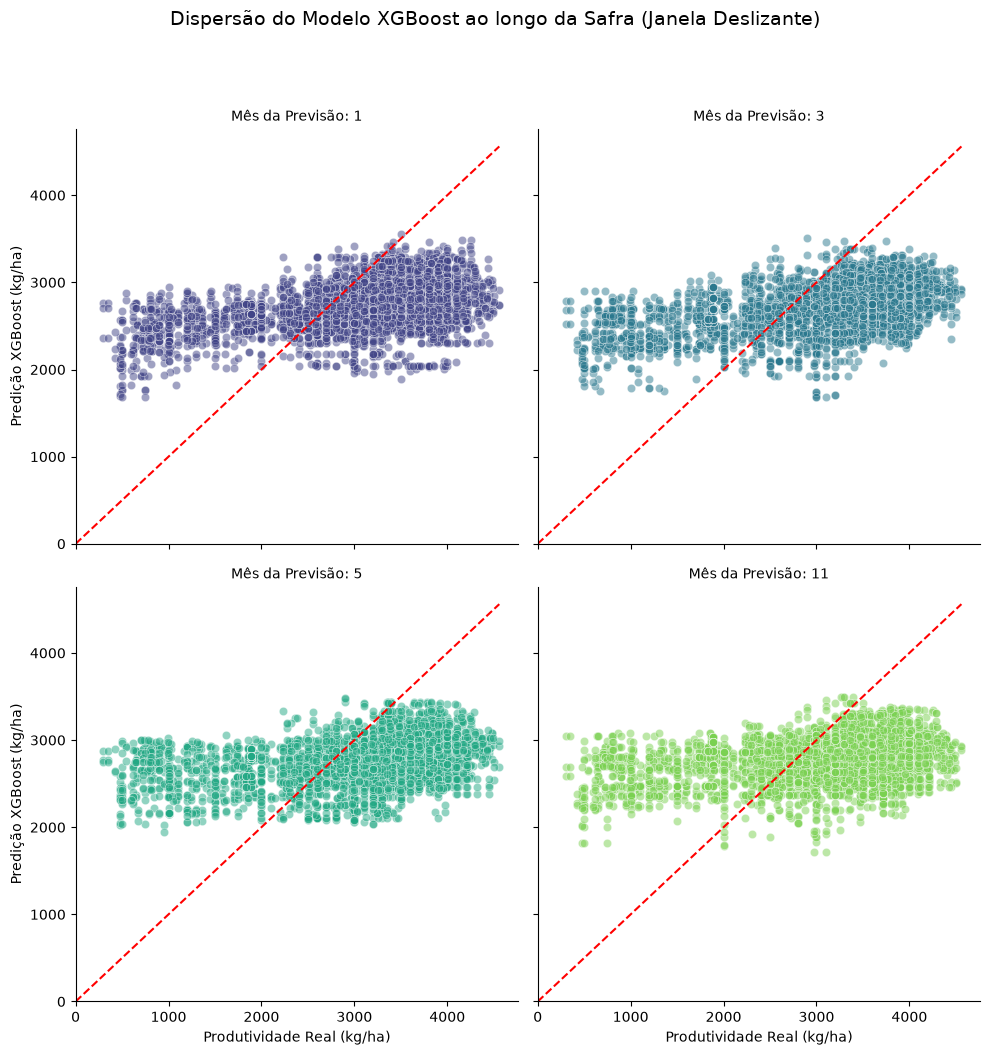

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Montando a tabela de comparação Real vs Predito por Município e Janela...")

# Criando o DataFrame de resultados usando os dados de teste (safras 2021-2024)
df_resultados = df_teste[['name', 'ano_safra', 'mes_previsao', 'janela_meses']].copy()
df_resultados['Produtividade_Real'] = y_test
df_resultados['Predicao_RF'] = y_pred_rf
df_resultados['Predicao_XGB'] = y_pred_xgb

# Calculando o quão longe (em kg/ha) o modelo passou da realidade para o XGBoost
df_resultados['Erro_Absoluto_XGB'] = abs(df_resultados['Produtividade_Real'] - df_resultados['Predicao_XGB'])

print("\nExemplo de Predições Individuais (Municípios no Teste Cego)")
display(df_resultados.sample(10, random_state=42))

print("Análise do Erro MAE (kg/ha) por Momento de Previsão e Janela Climática:")
# Agrupando pelo mês de previsão e tamanho da janela para avaliar a evolução da acurácia
erro_por_cenario = df_resultados.groupby(['mes_previsao', 'janela_meses'])['Erro_Absoluto_XGB'].mean().unstack()
erro_por_cenario.columns = [f'Janela {col} Mês(es)' for col in erro_por_cenario.columns]
erro_por_cenario.index = [f'Mês {idx}' for idx in erro_por_cenario.index]
display(erro_por_cenario)

print("Gerando gráficos separados por Mês de Previsão...")
# Usando o FacetGrid do Seaborn para separar os gráficos por mês automaticamente
g = sns.FacetGrid(
    df_resultados, 
    col="mes_previsao", 
    col_wrap=2, # Coloca 2 gráficos por linha
    height=5, 
    hue="mes_previsao", 
    palette="viridis"
)

# Plotando os pontos reais vs preditos
g.map(sns.scatterplot, "Produtividade_Real", "Predicao_XGB", alpha=0.5)

max_val = max(df_resultados['Produtividade_Real'].max(), df_resultados['Predicao_XGB'].max())
for ax in g.axes.flat:
    ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Acerto Perfeito')
    ax.set_xlim(0, max_val + 200)
    ax.set_ylim(0, max_val + 200)

g.set_axis_labels("Produtividade Real (kg/ha)", "Predição XGBoost (kg/ha)")
g.set_titles(col_template="Mês da Previsão: {col_name}")
g.fig.suptitle('Dispersão do Modelo XGBoost ao longo da Safra (Janela Deslizante)', y=1.05, fontsize=14)

plt.tight_layout()
plt.show()

## Comparando Baseline vs Ensembles

Comparando o Desempenho: Baseline (CART) vs Ensembles (RF, XGBoost)...


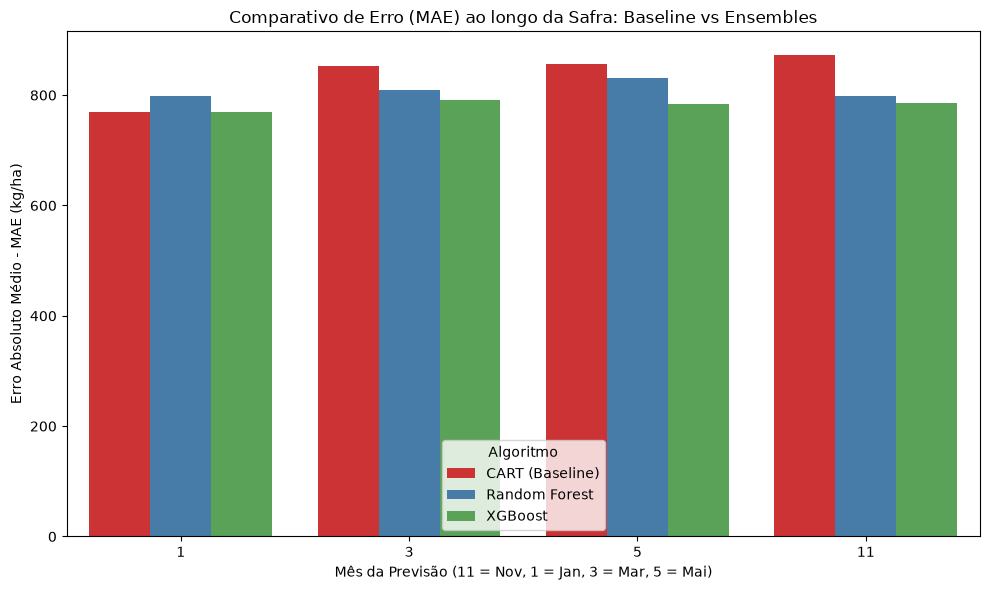


Tabela Numérica do Comparativo de MAE:


,Mês de Previsão,CART (Baseline),Random Forest,XGBoost
0,1,769.296355,797.659432,769.570183
1,3,852.847679,808.545216,791.215554
2,5,855.813236,830.260784,784.269514
3,11,872.020991,798.136685,785.809483


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Comparando o Desempenho: Baseline (CART) vs Ensembles (RF, XGBoost)...")

# Predições do CART
df_resultados['Predicao_CART'] = y_pred_cart

# Erro Absoluto para o CART e para o RF
df_resultados['Erro_CART'] = abs(df_resultados['Produtividade_Real'] - df_resultados['Predicao_CART'])
df_resultados['Erro_RF'] = abs(df_resultados['Produtividade_Real'] - df_resultados['Predicao_RF'])

erro_comparativo = df_resultados.groupby('mes_previsao')[['Erro_CART', 'Erro_RF', 'Erro_Absoluto_XGB']].mean().reset_index()

erro_comparativo = erro_comparativo.rename(columns={
    'mes_previsao': 'Mês de Previsão',
    'Erro_CART': 'CART (Baseline)',
    'Erro_RF': 'Random Forest',
    'Erro_Absoluto_XGB': 'XGBoost'
})

erro_melt = pd.melt(erro_comparativo, id_vars='Mês de Previsão', 
                    var_name='Modelo Preditivo', value_name='MAE (kg/ha)')

plt.figure(figsize=(10, 6))
sns.barplot(data=erro_melt, x='Mês de Previsão', y='MAE (kg/ha)', hue='Modelo Preditivo', palette='Set1')

plt.title('Comparativo de Erro (MAE) ao longo da Safra: Baseline vs Ensembles')
plt.ylabel('Erro Absoluto Médio - MAE (kg/ha)')
plt.xlabel('Mês da Previsão (11 = Nov, 1 = Jan, 3 = Mar, 5 = Mai)')
plt.legend(title='Algoritmo')
plt.tight_layout()
plt.show()

print("\nTabela Numérica do Comparativo de MAE:")
display(erro_comparativo)